## ARIMA

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from datetime import timedelta

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import seaborn as sns
import scipy.stats as stats
from sklearn.metrics import mean_absolute_error, mean_squared_error

### Step1: Load the data

In [2]:
#def load_cleaned_data(station_id, directory="../EDA_2025/cleaned_data"):
    #filename = f"{directory}/Station{station_id}_cleaned_data.csv"
    #df = pd.read_csv(filename, parse_dates=True, index_col=0)
    #df.index = pd.DatetimeIndex(df.index)
    #df.index.freq = 'H'
    #return df

def load_cleaned_data(station_id, directory="./output"):
    filename = f"{directory}/Station{station_id}_filled_shortgaps.csv"
    df = pd.read_csv(filename, parse_dates=True, index_col=0)
    df.index = pd.DatetimeIndex(df.index)
    df.index.freq = 'H'
    return df

def load_missing_data(station_id, directory="../EDA_2025/missing_data"):
    filename = f"{directory}/Station{station_id}_missing_data.csv"
    df = pd.read_csv(filename)
    return df

In [3]:
load_cleaned_data(1).head()

,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Flag,Tair,RH,Wind speed,Wind direction,Srad,Ppt
2015-01-01 00:00:00,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,3,-1.090,81.5,1.052,52.27,0.63,0.0
2015-01-01 01:00:00,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,3,-1.038,81.7,0.959,46.71,0.62,0.0
2015-01-01 02:00:00,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,3,-0.981,82.0,1.062,52.04,0.60,0.0
2015-01-01 03:00:00,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,3,-0.814,81.9,0.887,58.91,0.64,0.0
2015-01-01 04:00:00,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,3,-0.805,90.0,0.828,16.55,0.20,0.0


### Step2: Filter Medium gap data for ARIMA (Days to Weeks) (1–7 days) (24–168 hours)

In [4]:
def filter_medium_gaps(df_missing, parameter="SWC_5", min_gap=24, max_gap=168):
    # Convert "Number Missing" column to numeric
    df_missing["Number Missing"] = pd.to_numeric(df_missing["Number Missing"], errors="coerce")
    mask = (df_missing["Parameter"] == parameter) & \
           (df_missing["Number Missing"] >= min_gap) & (df_missing["Number Missing"] <= max_gap)
    return df_missing[mask]

### Step3: ARIMA Modeling and Imputation

In [5]:
def arima_forecast(series, start_ts, end_ts, exog_series=None, extra_days=7):
    # 1: Define the training window
    window_start = start_ts - pd.Timedelta(days=extra_days)
    window_end = end_ts + pd.Timedelta(days=extra_days)
    
    # 2: Extract the training data and drop missing values
    train = series[window_start:window_end].dropna()
    
    if train.empty:
        print(f"Not enough data available in window {window_start} to {window_end} for model fitting.")
        return None, None

    exog_train = None
    exog_pred  = None
    if exog_series is not None:
        exog_train = exog_series.loc[train.index]
        pred_index = pd.date_range(start_ts, end_ts, freq="H")
        exog_pred  = exog_series.reindex(pred_index)
        
    # 3: Use auto_arima to determine the best (p,d,q) order
    # NEED TO DO: ++ seasonality here turn to SARIMA
    auto_model = auto_arima(train,
                            seasonal=True,  m=24,      # daily seasonality
                            start_p=1, start_q=1, max_p=5, max_q=5,
                            d=None, D=1,               # allow 1 seasonal diff
                            start_P=1, start_Q=1, max_P=2, max_Q=2,
                            exogenous=exog_train,
                            error_action="ignore",
                            suppress_warnings=True)

    p, d, q = auto_model.order
    P, D, Q, s = auto_model.seasonal_order
    print(f"  auto_arima -> ({p},{d},{q}) x ({P},{D},{Q},{s})")

    results = SARIMAX(train,
                    exog=exog_train,
                    order=(p, d, q),
                    seasonal_order=(P, D, Q, s),
                    enforce_stationarity=False,
                    enforce_invertibility=False).fit(method='powell', maxiter=500, disp=False)

    idx = pd.date_range(start_ts, end_ts, freq="H")
    forecast_series = results.forecast(len(idx), exog=exog_pred)
    forecast_series.index = idx
    return forecast_series, results

### Step4: Visualize the Imputation Result

In [6]:
def plot_imputation_result(series, start_missing, end_missing, imputed_series, pre_days=3, post_days=3):
    plot_start = start_missing - pd.Timedelta(days=pre_days)
    plot_end = end_missing + pd.Timedelta(days=post_days)
    
    plt.figure(figsize=(10, 4))
    plt.plot(series.loc[plot_start:plot_end], label="Imputed Data")
    plt.axvspan(start_missing, end_missing, color="gray", alpha=0.3, label="Missing Interval")
    plt.title(f"Imputation Result for Interval {start_missing} to {end_missing}")
    plt.xlabel("Time")
    plt.ylabel(series.name)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_diag(res, lags=24):
    resid = res.resid
    fig, ax = plt.subplots(1,1, figsize=(9,3))
    ax.plot(resid); ax.set_title("Residuals")
    plt.show()
    plot_acf(resid, lags=lags); plt.show()


### Step5: Main Function

In [7]:
def main(station, param, extra_days):
    df = load_cleaned_data(station)
    # We decide to treat station3 as reference 
    df_ref  = load_cleaned_data(3)
    ppt_main = df.get("Ppt", pd.Series(dtype=float))
    ppt_ref  = df_ref.get("Ppt", pd.Series(dtype=float)).reindex(df.index)
    exog = ppt_main.fillna(ppt_ref).fillna(0)
    
    gaps = load_missing_data(station)
    m_gaps = filter_medium_gaps(gaps, param)
    
    if m_gaps.empty:
        print("No 1–7 day gaps.")
        return

    print(m_gaps[["Start Timestamp","End Timestamp","Number Missing"]])

    for _, row in m_gaps.iterrows():
        s_ts = pd.to_datetime(row["Start Timestamp"])
        e_ts = pd.to_datetime(row["End Timestamp"])
        print(f"\nImputing {s_ts} – {e_ts}")

        forecast_series, results = arima_forecast(
            df[param], s_ts, e_ts, exog_series=exog, extra_days=extra_days)

        if forecast_series is None:
            continue

        left  = df[param].loc[s_ts - pd.Timedelta(hours=1)]
        right = df[param].loc[e_ts   + pd.Timedelta(hours=1)]
        forecast_series.iloc[0]  = 0.5*left  + 0.5*forecast_series.iloc[0]
        forecast_series.iloc[-1] = 0.5*right + 0.5*forecast_series.iloc[-1]
        
        df.loc[forecast_series.index, param] = forecast_series

        # diagnose
        plot_diag(results)

        # quick plot
        plot_imputation_result(df[param], s_ts, e_ts, forecast_series)

    # output
    out = f"Station{station}_{param}_filled_mediumgaps.csv"
    df.to_csv(out)
    print(f"\nSaved → {out}")

        Start Timestamp        End Timestamp  Number Missing
38  2017-06-09 09:00:00  2017-06-12 02:00:00              66
43  2017-07-01 14:00:00  2017-07-06 07:00:00             114

Imputing 2017-06-09 09:00:00 – 2017-06-12 02:00:00
  auto_arima -> (1,1,0) x (0,1,1,24)


C:\Users\13464\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\13464\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\13464\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\13464\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_pre

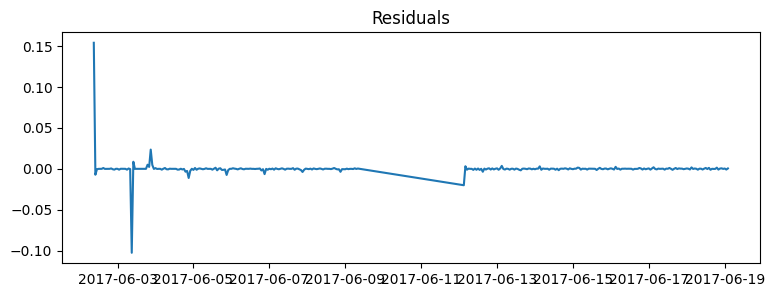

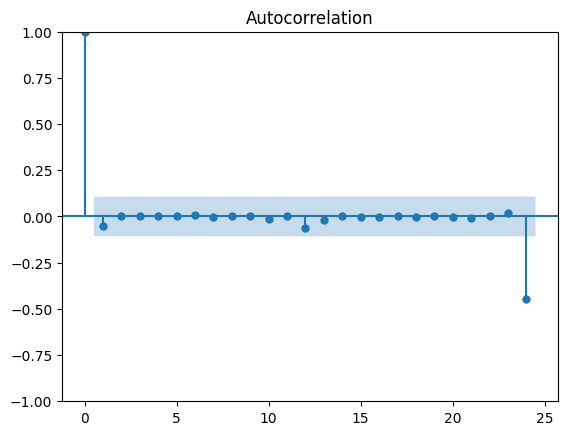

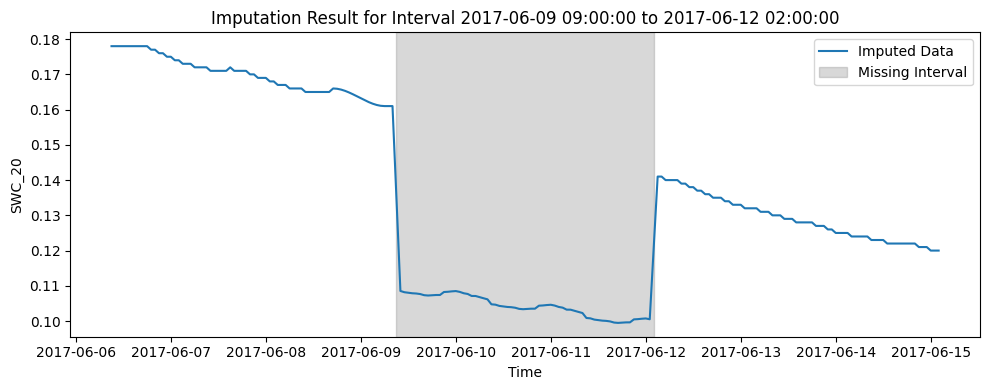


Imputing 2017-07-01 14:00:00 – 2017-07-06 07:00:00
  auto_arima -> (2,1,0) x (0,1,2,24)


C:\Users\13464\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\13464\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\13464\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\13464\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_pre

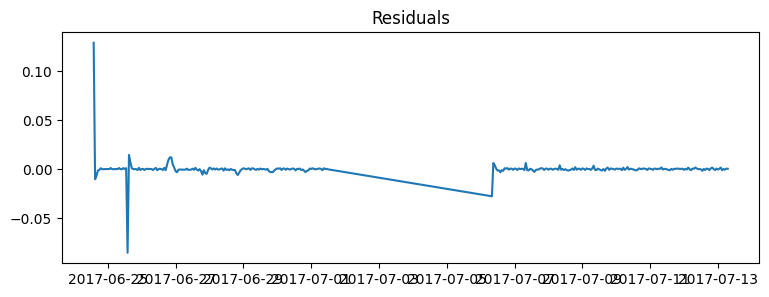

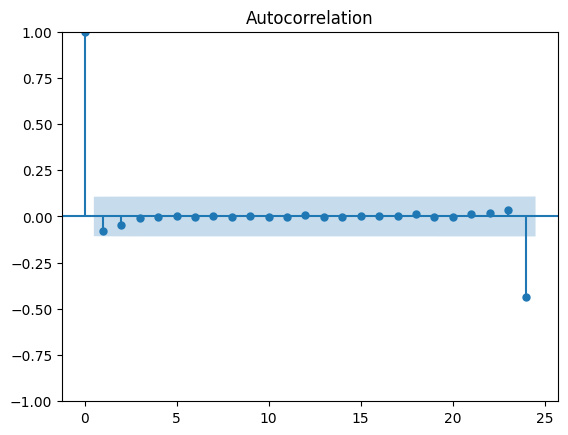

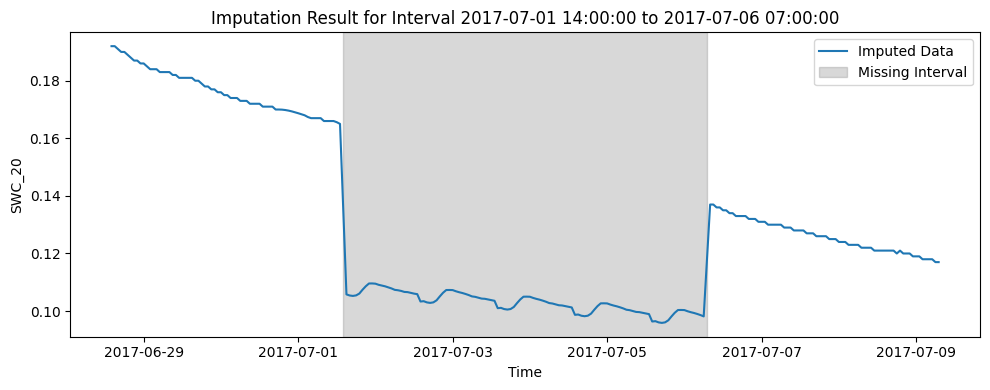


Saved → Station1_SWC_20_filled_mediumgaps.csv


In [10]:
main(station=1, param="SWC_20", extra_days=7)

Questions:
- 1.
Should we first fill in the short gaps (like using moving averages), and then use that filled data to train ARIMA models for the medium gaps—and then use the medium gap-filled data for the long gaps? Or should we handle each gap type separately and merge everything at the end?

- 2.
Do you think we should stick with auto_arima for efficiency since we have a lot of gaps? Or is it better to manually check the ACF/PACF plots and choose p, d, q ourselves for better results?

In [9]:
df = load_cleaned_data(3)
exog = df["Ppt"] if "Ppt" in df.columns else None
exog.head()
exog.isna().sum()


0